<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/ESO002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'viridis'


In [ ]:
# Grid
Nx, Ny = 128, 128
Lx, Ly = 1.0, 1.0
dx, dy = Lx / Nx, Ly / Ny
assert abs(dx - dy) < 1e-12
h = dx

# Time (shorter run to see dynamics)
dt = 1e-4
n_steps = 400
save_every = 20

# HES backbone (no anchor)
D0 = 0.12
D1 = 0.05
lam = 0.0      # anchor OFF
eta = 0.04

# Curvature proxy
a = 0.45
b = 0.12

# Curvature response
chi = 0.28

# Species EOS parameters
w = np.array([0.0, 1.0/3.0, -0.4])
alpha = np.array([0.9, 1.3, -0.7])
beta = np.array([0.0, 0.0, 0.0])

# Coupling strengths
kappa = np.array([0.6, 0.8, 0.5])

# Species diffusion
D_rho = np.array([0.01, 0.02, 0.01])
n_species = 3


In [ ]:
# --- EOS Experiment Toggle Block ---

# Choose experiment mode:
# 0 = baseline
# 1 = stronger negative-pressure species 3
# 2 = stronger radiation species 2
# 3 = all species amplified
EOS_MODE = 0

if EOS_MODE == 1:
    # Species 3: more exotic
    w[2] = -0.8
    alpha[2] = -1.0
    kappa[2] = 0.5
    print("EOS experiment: stronger exotic species 3")

elif EOS_MODE == 2:
    # Species 2: more radiation-like
    w[1] = 0.5
    alpha[1] = 1.5
    kappa[1] = 0.8
    print("EOS experiment: stronger radiation species 2")

elif EOS_MODE == 3:
    # All species amplified
    w[:] = np.array([0.1, 0.5, -0.6])
    alpha[:] = np.array([1.0, 1.5, -1.2])
    kappa[:] = np.array([0.6, 0.8, 0.5])
    print("EOS experiment: all species amplified")

else:
    print("EOS experiment: baseline")


EOS experiment: baseline


In [ ]:
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.5 * Lx, 0.5 * Ly
R = np.sqrt((X - xc)**2 + (Y - yc)**2)


In [ ]:
# Harmonic well for S
S0 = 1.0
A = 4.0
S = S0 - A * ((X - xc)**2 + (Y - yc)**2)

# Small noise
S += 0.02 * np.random.randn(Nx, Ny)

# Anchor manifold S_star
S_star = S0 - A * ((X - xc)**2 + (Y - yc)**2)

# Species densities
rho = np.zeros((n_species, Nx, Ny))

# Species 1: central blob
rho[0] = np.exp(-40.0 * ((X - xc)**2 + (Y - yc)**2))

# Species 2: annulus
rho[1] = np.exp(-40.0 * (R - 0.25)**2)

# Species 3: two lobes
rho[2] = (
    np.exp(-50.0 * ((X - 0.25)**2 + (Y - 0.75)**2)) +
    np.exp(-50.0 * ((X - 0.75)**2 + (Y - 0.25)**2))
)


In [ ]:
def compute_curvature(S, h):
    lapS = laplacian(S, h)
    gradS2 = grad_sq(S, h)
    K = a * lapS + b * gradS2
    return K, lapS, gradS2


def compute_pressures(S, rho):
    P = np.zeros_like(rho)
    for i in range(n_species):
        P[i] = w[i] * rho[i] + alpha[i] * S + beta[i] * S**2
    return P


def compute_couplings(P, K):
    C = np.zeros_like(P)
    factor = (1.0 + chi * K)
    for i in range(n_species):
        C[i] = kappa[i] * P[i] * factor
    return C


def rhs_S(S, rho, S_star, h):
    K, lapS, gradS2 = compute_curvature(S, h)
    P = compute_pressures(S, rho)
    C = compute_couplings(P, K)

    C_sum = np.sum(C, axis=0)

    F = (
        D0 * lapS +
        D1 * gradS2 +
        C_sum -
        eta * S**3
    )
    return F


In [ ]:
def rhs_rho(rho, h):
    drho_dt = np.zeros_like(rho)
    for i in range(n_species):
        drho_dt[i] = D_rho[i] * laplacian(rho[i], h)
    return drho_dt


In [ ]:
def step_RK2(S, rho, S_star, h, dt):
    # S update
    F1 = rhs_S(S, rho, S_star, h)
    S_p = S + dt * F1
    F2 = rhs_S(S_p, rho, S_star, h)
    S_new = S + 0.5 * dt * (F1 + F2)

    # Clamp S
    S_new = np.clip(S_new, -2.0, 2.0)

    # rho update
    G1 = rhs_rho(rho, h)
    rho_p = rho + dt * G1
    G2 = rhs_rho(rho_p, h)
    rho_new = rho + 0.5 * dt * (G1 + G2)

    # Prevent negative densities
    rho_new = np.maximum(rho_new, 0.0)

    return S_new, rho_new


In [ ]:
S_hist = []
K_hist = []

S_curr = S.copy()
rho_curr = rho.copy()

for step in range(n_steps):
    S_curr, rho_curr = step_RK2(S_curr, rho_curr, S_star, h, dt)

    if step % save_every == 0:
        K_curr, _, _ = compute_curvature(S_curr, h)
        S_hist.append(S_curr.copy())
        K_hist.append(K_curr.copy())
        print(f"Step {step}/{n_steps}")


Step 0/400
Step 20/400
Step 40/400
Step 60/400
Step 80/400
Step 100/400
Step 120/400
Step 140/400
Step 160/400
Step 180/400
Step 200/400
Step 220/400
Step 240/400
Step 260/400
Step 280/400
Step 300/400
Step 320/400
Step 340/400
Step 360/400
Step 380/400


In [ ]:
# --- EOS Experiment Toggle Block ---

# Choose experiment mode:
# 0 = baseline
# 1 = stronger negative-pressure species 3
# 2 = stronger radiation species 2
# 3 = all species amplified
EOS_MODE = 0

if EOS_MODE == 1:
    # Species 3: more exotic
    w[2] = -0.8
    alpha[2] = -1.0
    kappa[2] = 0.5
    print("EOS experiment: stronger exotic species 3")

elif EOS_MODE == 2:
    # Species 2: more radiation-like
    w[1] = 0.5
    alpha[1] = 1.5
    kappa[1] = 0.8
    print("EOS experiment: stronger radiation species 2")

elif EOS_MODE == 3:
    # All species amplified
    w[:] = np.array([0.1, 0.5, -0.6])
    alpha[:] = np.array([1.0, 1.5, -1.2])
    kappa[:] = np.array([0.6, 0.8, 0.5])
    print("EOS experiment: all species amplified")

else:
    print("EOS experiment: baseline")


EOS experiment: baseline


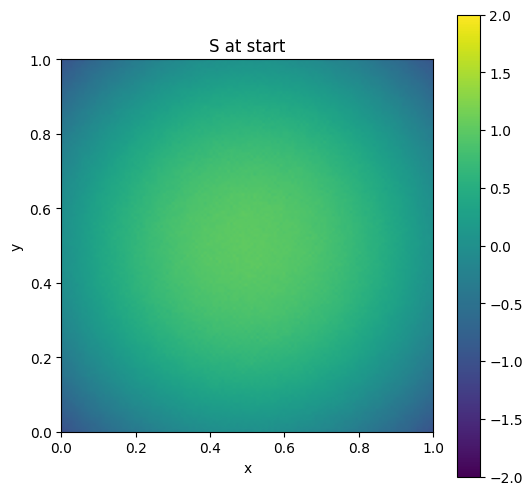

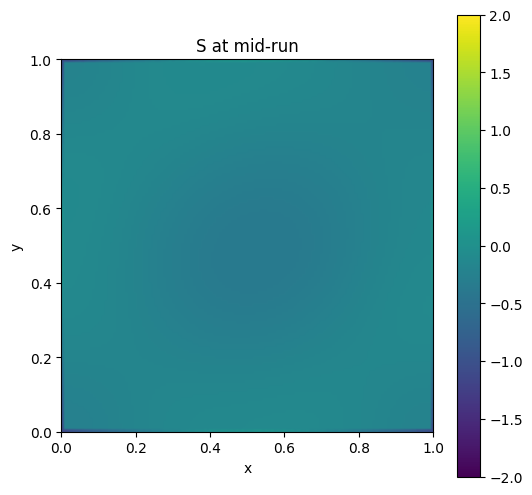

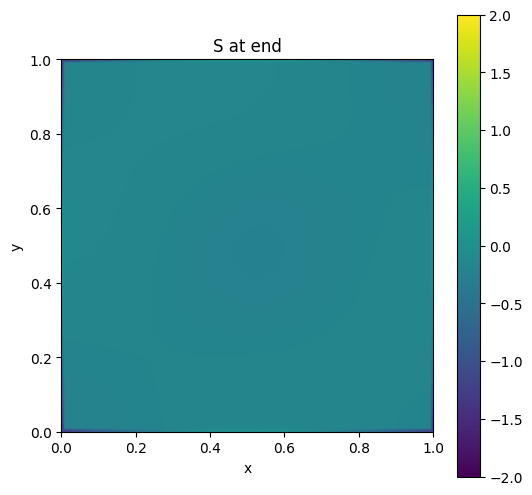

In [ ]:
# --- Time Evolution Snapshots ---

def plot_snapshot(S_hist, idx, title):
    S_frame = S_hist[idx]
    plot_field(S_frame, title=title, vmin=-2.0, vmax=2.0)

# Early, mid, late snapshots
plot_snapshot(S_hist, 0, "S at start")
plot_snapshot(S_hist, len(S_hist)//2, "S at mid-run")
plot_snapshot(S_hist, -1, "S at end")
